In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from torchvision import transforms as T
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
mnist_transform = T.Compose(
    [
        T.Resize((64, 64)),
        T.ToTensor()
    ]
)

train_dataset = MNIST('dataset/mnist', download = True, train = True, transform = mnist_transform)
valid_dataset = MNIST('dataset/mnist', download = True, train = True, transform = mnist_transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 4, pin_memory = True)
valid_loader = DataLoader(valid_dataset, batch_size = 64, shuffle = False, num_workers = 4, pin_memory = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]


In [3]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 5)

In [4]:
from tqdm import tqdm
def train(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for x, _ in tqdm(loader, desc = 'Train'):
        x = x.to(device)

        optimizer.zero_grad()
        
        output = model(x)
        
        loss = loss_fn(output, x)
        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()
    total_loss /= len(loader)
    return total_loss

In [5]:
@torch.inference_mode()
def evaluate(model, loader, loss_fn):
    model.eval()
    
    total_loss = 0

    for x, _ in tqdm(loader, desc = 'Evaluate'):
        x = x.to(device)
        output = model(x)
        loss = loss_fn(output, x)
        total_loss += loss.item()
    total_loss /= len(loader)
    return total_loss

In [6]:
def plot_stats(
    train_loss : list[float],
    valid_loss : list[float],
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss, label = 'Train loss')
    plt.plot(valid_loss, label = 'Valid loss')
    plt.legend()
    plt.grid()
    plt.show()

In [7]:
# берет несколько картинок - возвращает 1 тензор, все картинки в одной сетке
from torchvision.utils import make_grid

@torch.inference_mode()
def visualize(model, xs):
    model.eval()
    to_pil = T.ToPILImage()

    output = model(xs.to(device)).cpu()
    plt.figure(figsize = (16, 10))

    plt.imshow(
        to_pil(
            torch.cat(
                (
                    make_grid(xs[:10], nrow = 10, pad_value = 1),
                    make_grid(output[:10], nrow = 10, pad_value = 1)
                ),
                dim = 1
            )
        )
    )

    plt.axis('off')
    plt.show()

In [8]:
from IPython.display import clear_output
def whole_train_value_cycle(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    num_epochs,
    title
):
    train_loss_history, valid_loss_history = [], []
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn)
        valid_loss = evaluate(model, valid_loader, loss_fn)
        
        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait = True)

        visualize(model, next(iter(valid_loader))[0])
        plot_stats(train_loss_history, valid_loss_history, title)
        

### Соберем автоэнкодер

In [9]:
from torch import nn
import math
class Block(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, upsample: bool = False):
        super().__init__()
        self.upsample = upsample
        self.conv = nn.Conv2d(
            in_channels = in_channels,
            out_channels = out_channels,
            kernel_size = kernel_size,
            stride = stride,
            padding = 1,
            bias = False
        )
        self.norm = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU(0.2)

    def forward(self, x):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor = 2, mode = 'bilinear', align_corners = False, recompute_scale_factor = False)

        return self.act(self.norm(self.conv(x)))

class AutoEncoder(nn.Module):
    def __init__(self, in_channels: int, base_block: nn.Module = Block, base_size: int = 32, num_blocks: int = 4):
        super().__init__()
        self.base_size = base_size

        # создадим encoder

        encoder_blocks = []
        for i in range(num_blocks):
            encoder_blocks.append(
                base_block(
                    in_channels = base_size if i else in_channels,
                    out_channels = base_size,
                    kernel_size = 3,
                    stride = 2 # уменьшаем тензор в 2 раза
                )
            )
        encoder_blocks.append(
            base_block(
                in_channels = base_size,
                out_channels = base_size,
                kernel_size = 3
            ).conv
        )

        self.encoder = nn.Sequential(*encoder_blocks)

        # создадим decoder

        decoder_blocks = []
        for i in range(num_blocks):
            decoder_blocks.append(
                base_block(
                    in_channels = base_size,
                    out_channels = base_size,
                    kernel_size = 3,
                    upsample = True # уменьшаем тензор в 2 раза
                )
            )
        decoder_blocks.append(
            base_block(
                in_channels = base_size,
                out_channels = in_channels,
                kernel_size = 3
            ).conv
        )
        decoder_blocks.append(nn.Sigmoid())

        self.decoder = nn.Sequential(*decoder_blocks)

        self.flatten = nn.Flatten()

    def forward(self, x):
        # x.shape = [batch_size, in_channels, N, N]
        x = self.encoder(x)
        # x.shape = [batch_size, base_size, N / (2^num_blocks), N / (2^num_blocks)]
        x = self.decoder(x)
        # x.shape = [batch_size, in_channels, N, N]

        return x

    @torch.inference_mode()
    def encode(self, x):
        # x.shape = [batch_size, in_channels, N, N]
        return self.flatten(self.encoder(x)) # output.shape = [batch_size, base_size * N ** 2 / (2 ** num_blocks) ** 2]

    @torch.inference_mode()
    def decode(self, x):
        # x.shape = [batch_size, base_size * N ** 2 / (2 ** num_blocks) ** 2]
        latent_size = int(math.sqrt(x.shape[1] // self.base_size))

        # превращаем двумерный тензор в четырехмерный тензор
        return self.decoder(x.view(-1, self.base_size, latent_size, latent_size)) # output.shape = [batch_size, in_channels, N, N]

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

loss_fn = nn.MSELoss()

In [11]:
from torch.optim import Adam
model = AutoEncoder(in_channels = 1).to(device)
optimizer = Adam(model.parameters(), lr = 1e-3)

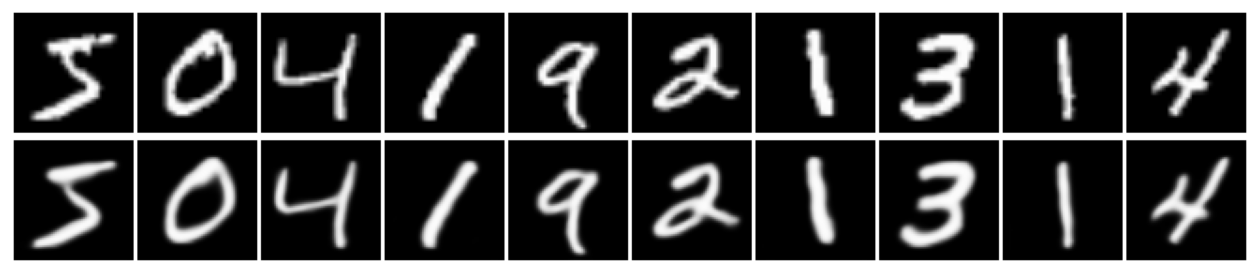

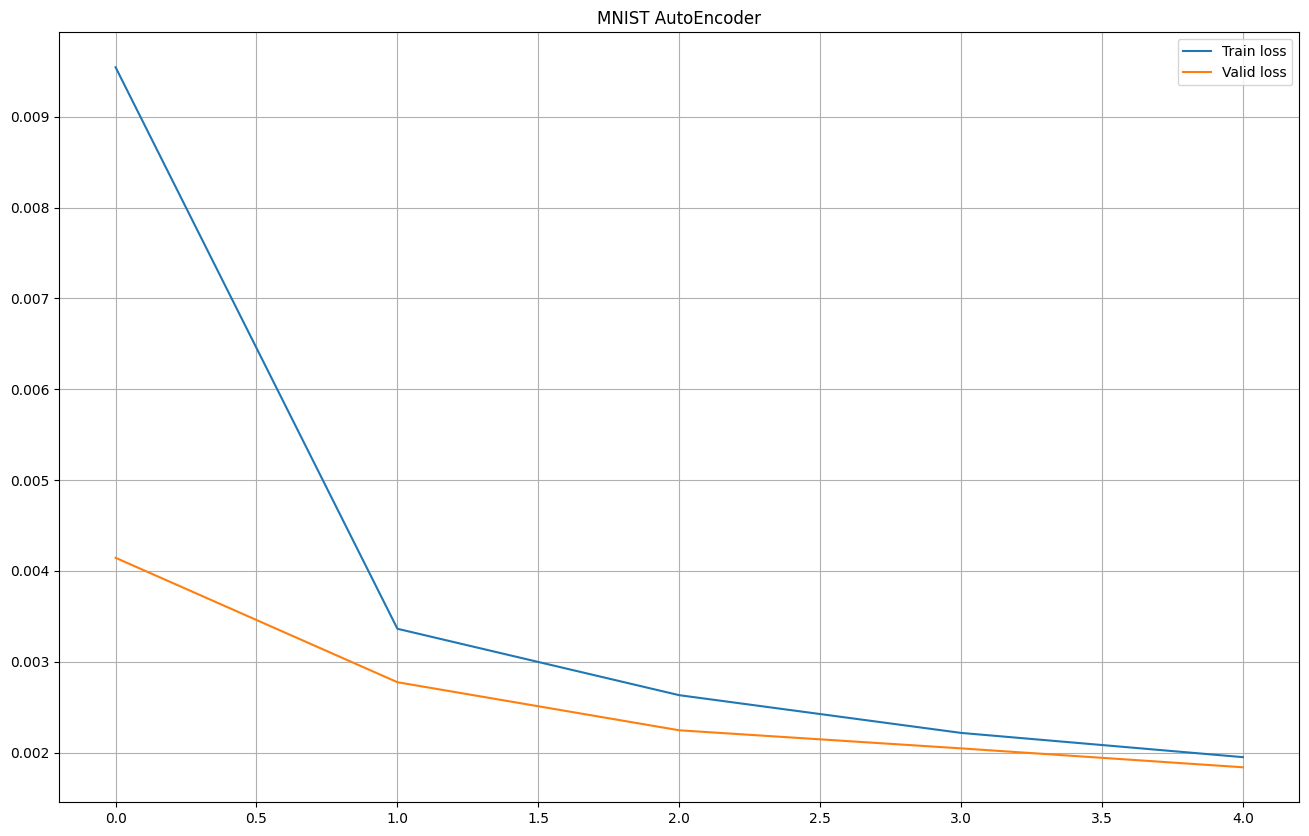

In [12]:
whole_train_value_cycle(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    5,
    'MNIST AutoEncoder'
)

In [13]:
@torch.inference_mode()
def get_interpolation(model, x1, x2):
    # получили эмбеддинги
    z1 = model.encode(x1.unsqueeze(0).to(device))
    z2 = model.encode(x2.unsqueeze(0).to(device))
    
    # получим веса для генерации картинок между этими двумя
    weights = torch.linspace(start = 0, end = 1, steps = 7).unsqueeze(1).to(device)
    zs = z2 * weights + z1 * (1 - weights)

    # представим их в виде изображений
    images = model.decode(zs)

    # выведем на экран
    plt.figure(figsize = (16, 10))
    plt.imshow(T.ToPILImage()(make_grid(images, nrow = 7, pad_value = 1)))
    plt.axis('off')
    plt.show()

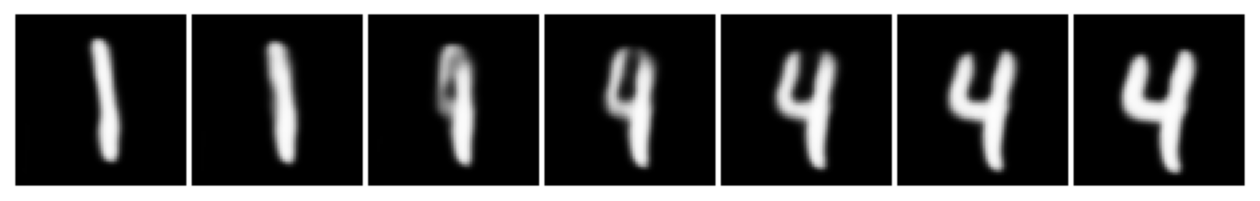

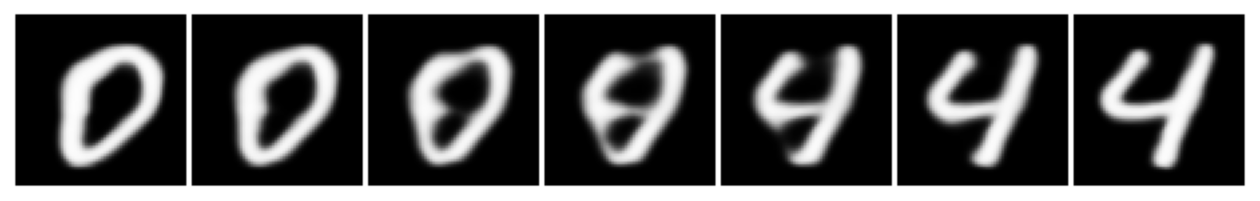

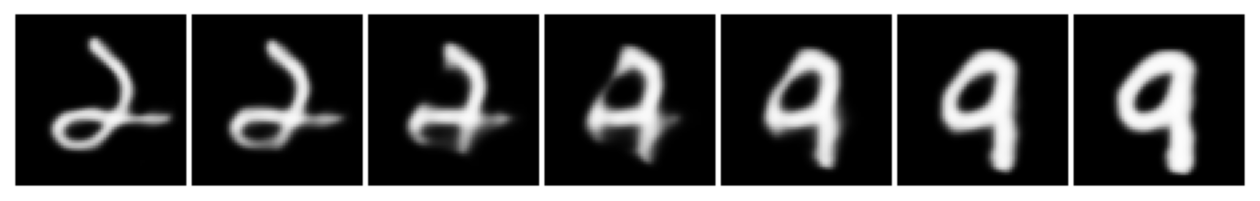

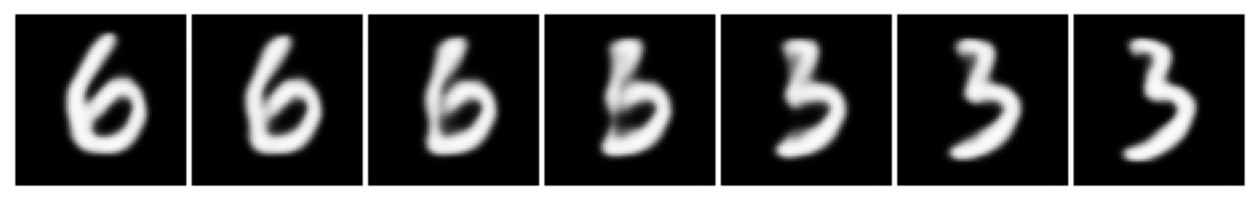

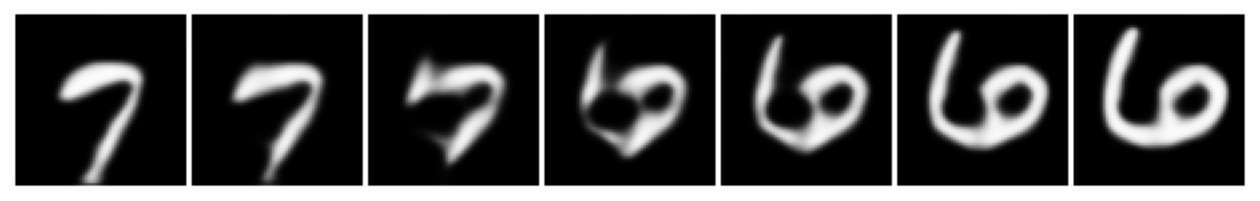

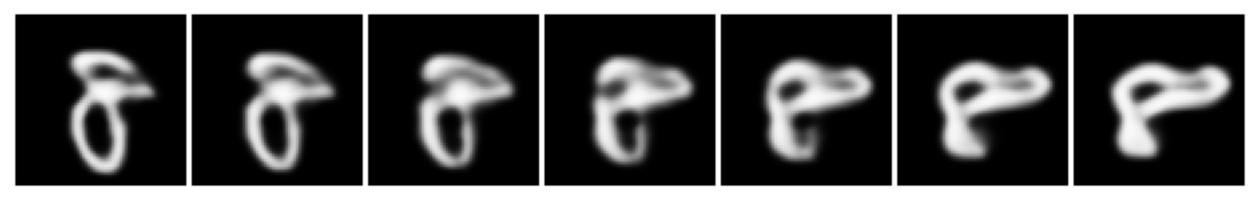

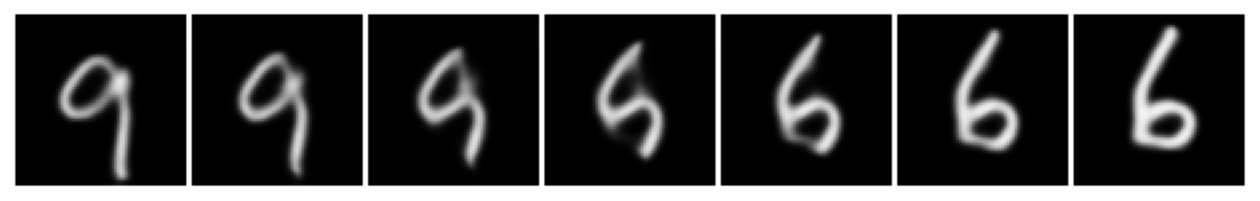

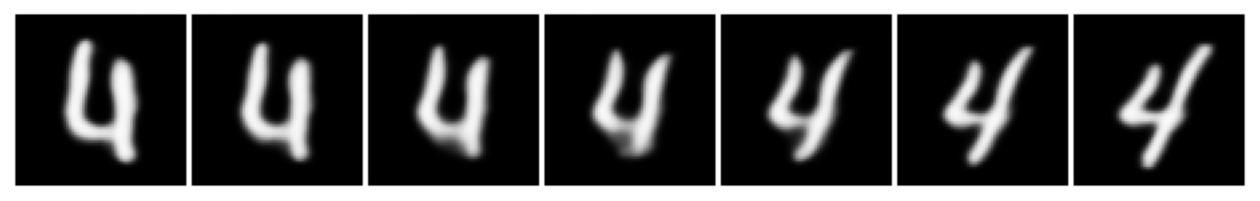

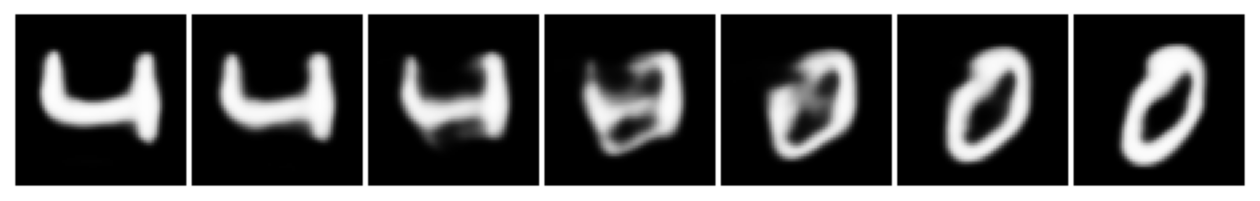

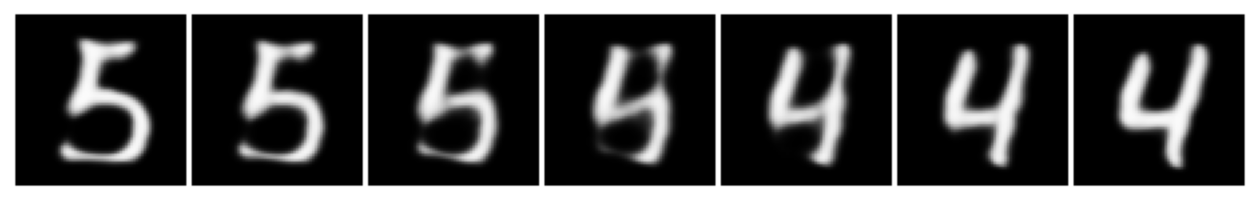

In [14]:
for _ in range(10):
    idx1, idx2 = np.random.randint(len(valid_dataset), size = 2)
    get_interpolation(model, valid_dataset[idx1][0], valid_dataset[idx2][0])
    

### Создадим DenoisingAutoEncoder (зашумляем данные при обучении)

In [15]:
from torch import nn
import math
class DenoisingBlock(Block):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, upsample: bool = False):
        super().__init__(in_channels, out_channels, kernel_size, stride, upsample)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor = 2, mode = 'bilinear', align_corners = False, recompute_scale_factor = False)

        # зашумляем на каждом этапе (на каждом блоке)
        if self.training:
            #rand_like - делает тензор такой же размерности, заполненный случайными числами от 0 до 1
            x = x + torch.rand_like(x) * 0.05

        return self.act(self.norm(self.conv(x)))

class DenoisingAutoEncoder(AutoEncoder):
    def __init__(self, in_channels: int, base_block: nn.Module = DenoisingBlock, base_size: int = 32, num_blocks: int = 4):
        super().__init__(in_channels, base_block, base_size, num_blocks)
        
    def forward(self, x):
        if self.training:
            # если числа меньше min - делает min, если больше max - делает max (обрезает значения)
            x = torch.clip(x + torch.rand_like(x) * 0.1, min = 0, max = 1)
        # x.shape = [batch_size, in_channels, N, N]
        x = self.encoder(x)
        # x.shape = [batch_size, base_size, N / (2^num_blocks), N / (2^num_blocks)]
        x = self.decoder(x)
        # x.shape = [batch_size, in_channels, N, N]

        return x

In [16]:
denoising_model = DenoisingAutoEncoder(in_channels = 1).to(device)
optimizer = Adam(denoising_model.parameters(), lr = 1e-3)

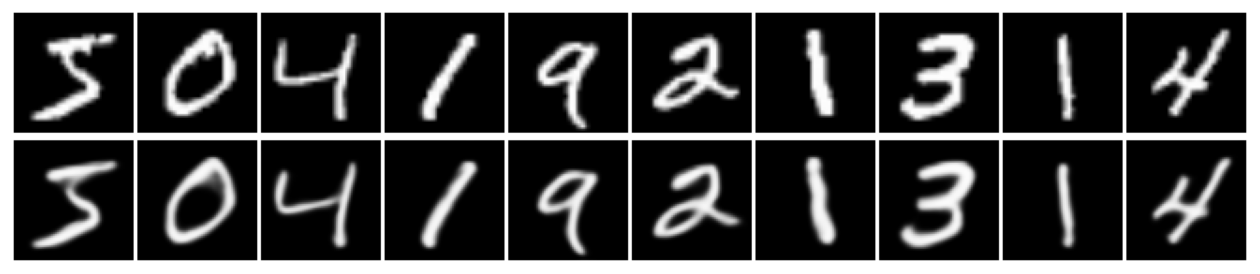

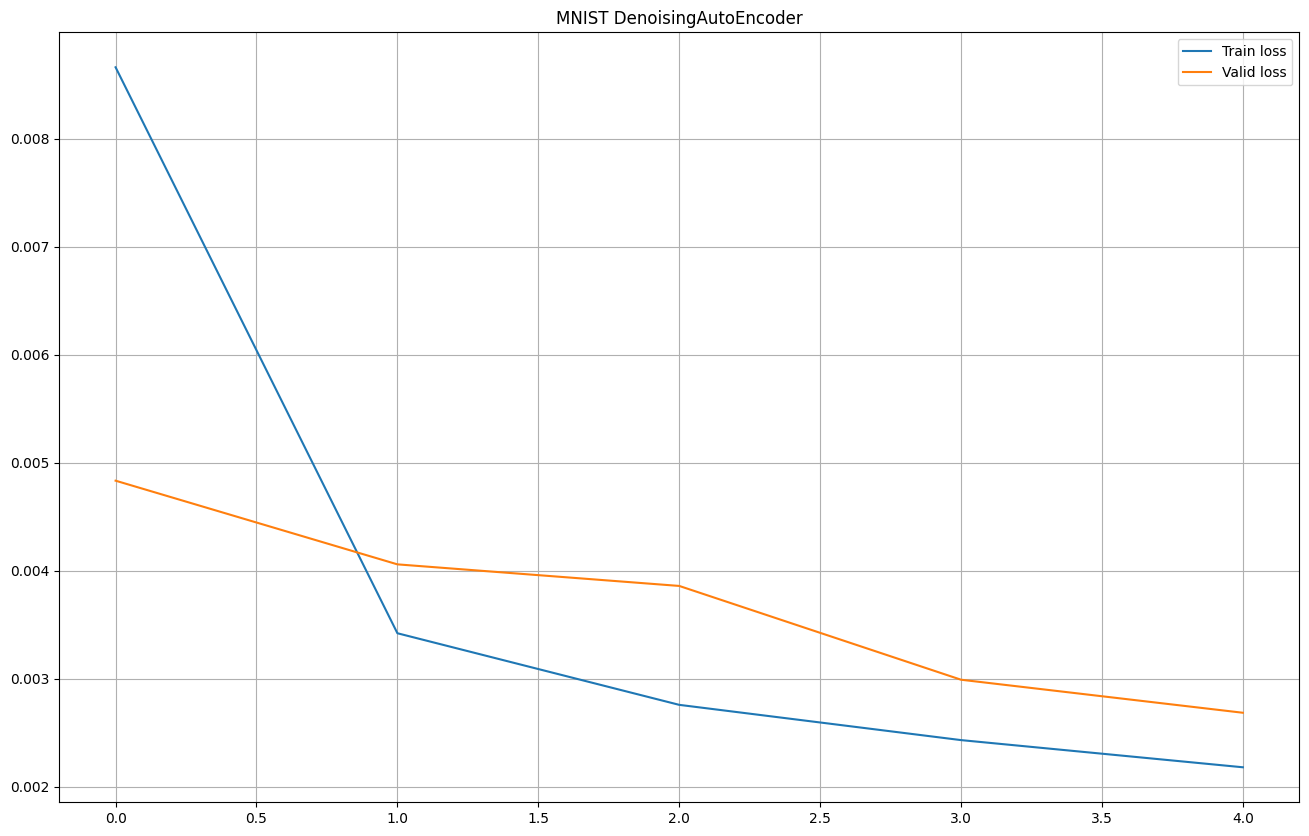

In [17]:
whole_train_value_cycle(
    denoising_model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    5,
    'MNIST DenoisingAutoEncoder'
)

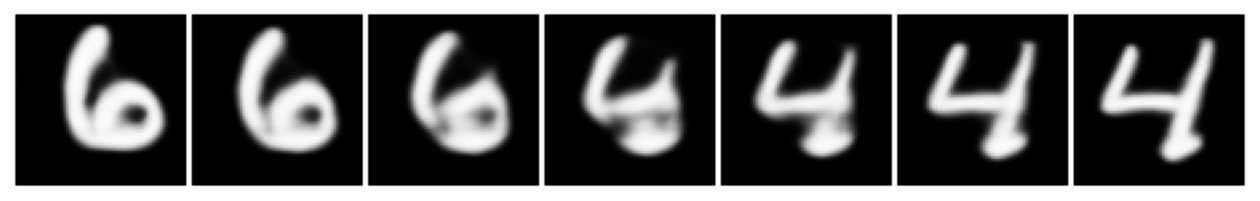

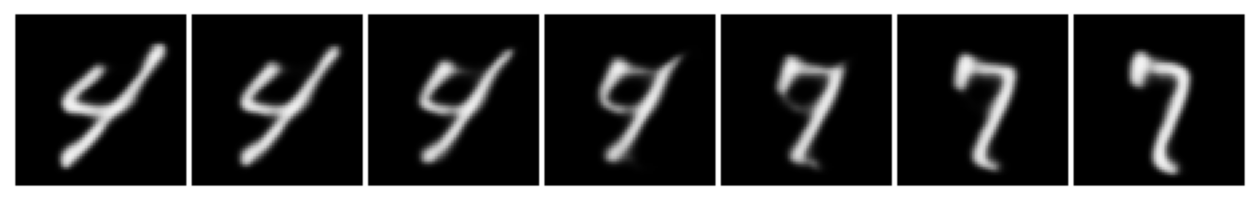

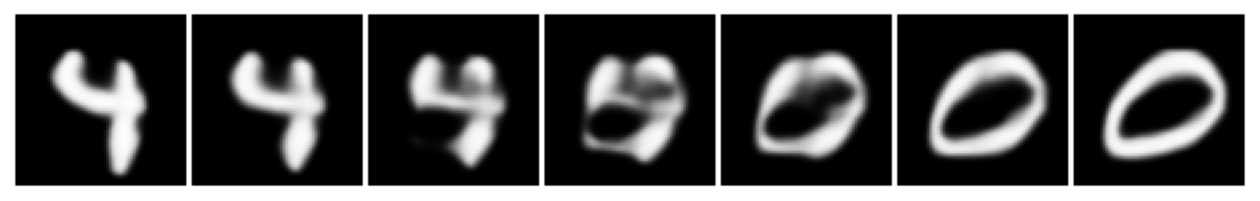

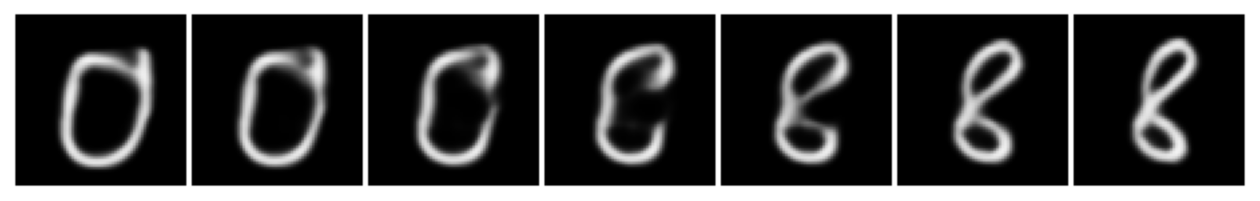

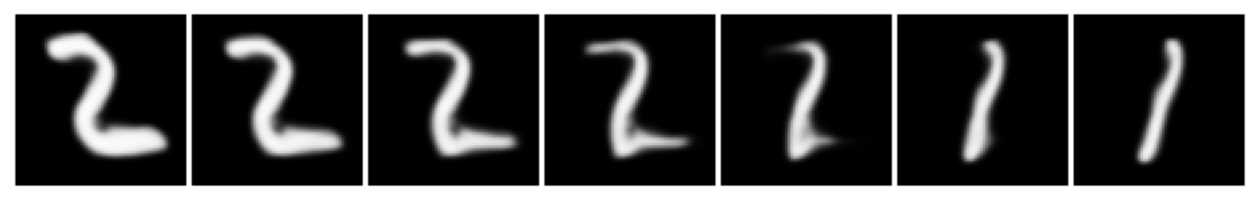

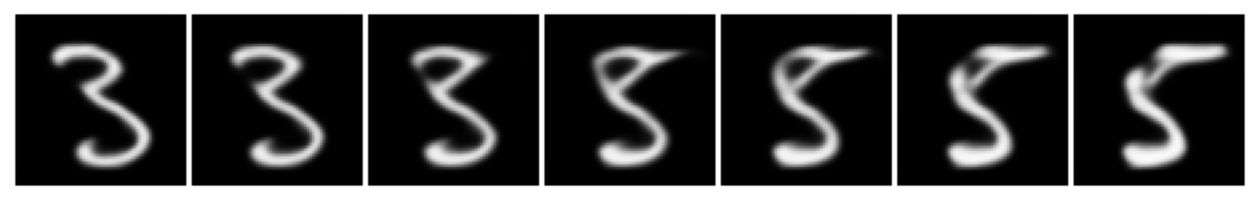

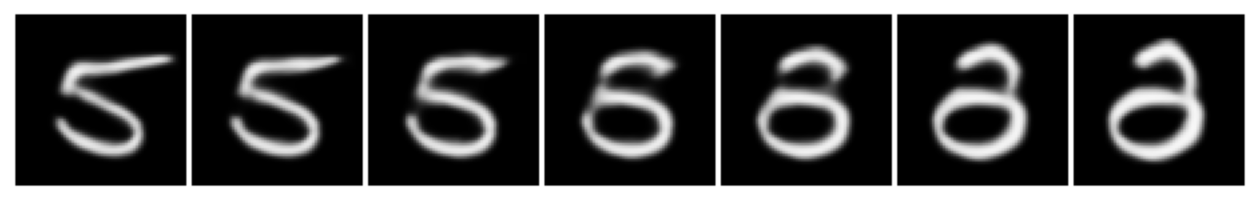

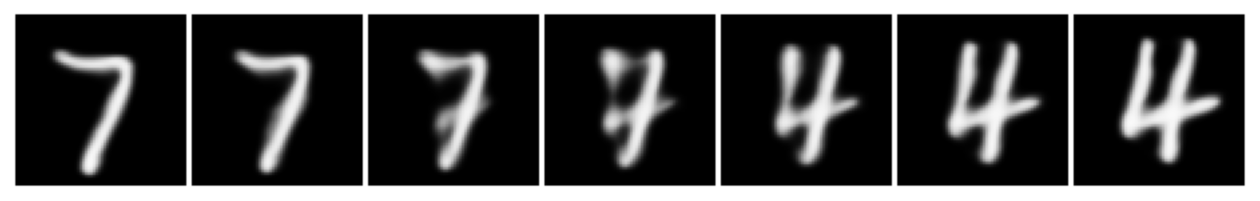

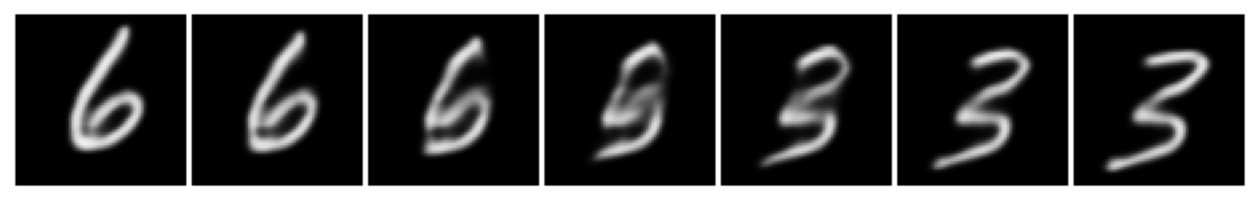

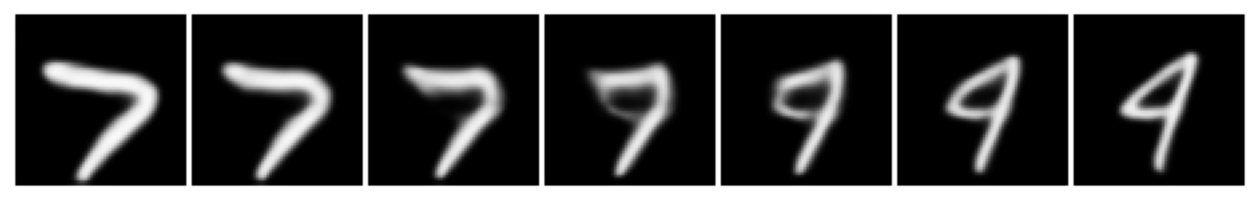

In [18]:
for _ in range(10):
    idx1, idx2 = np.random.randint(len(valid_dataset), size = 2)
    get_interpolation(denoising_model, valid_dataset[idx1][0], valid_dataset[idx2][0])

In [19]:
class AddNoise:
    def __init__(self, noise_level: float = 0.1):
        self.noise_level = noise_level

    def __call__(self, x):
        return torch.clip(x + torch.rand_like(x) * self.noise_level, min = 0, max = 1)

class FlipRandomBits:
    def __init__(self, flip_ratio = 0.1):
        self.flip_ratio = flip_ratio

    def __call__(self, x):
        # те рандомные биты, значение которых меньше self.flip_ration
        mask = torch.rand_like(x) < self.flip_ratio
        x[mask] = 1 - x[mask]
        return x

def test_denoising(model):
    transforms = (AddNoise(), AddNoise(0.25), FlipRandomBits())

    for transform in transforms:
        print('-' * 60)

        for i, batch in enumerate(valid_loader):
            visualize(model, transform(batch[0]))
            break

------------------------------------------------------------


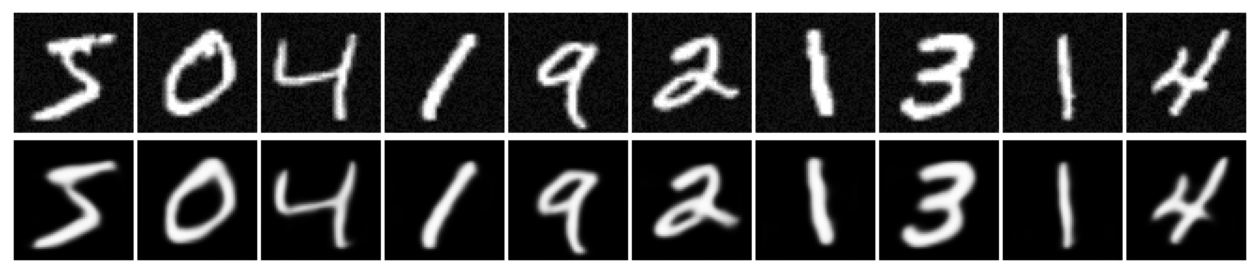

------------------------------------------------------------


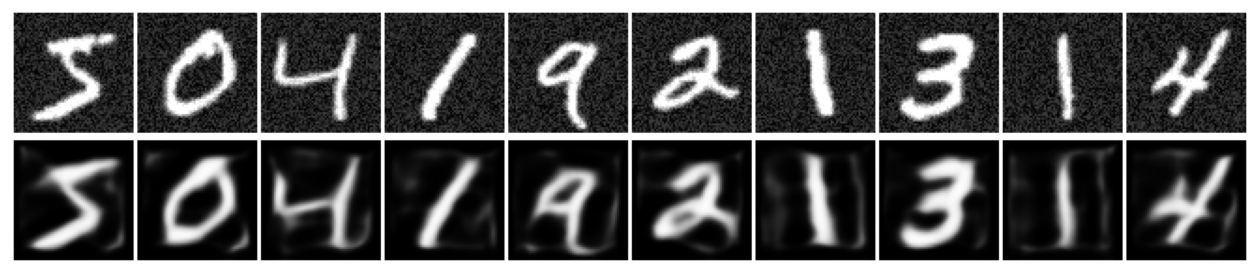

------------------------------------------------------------


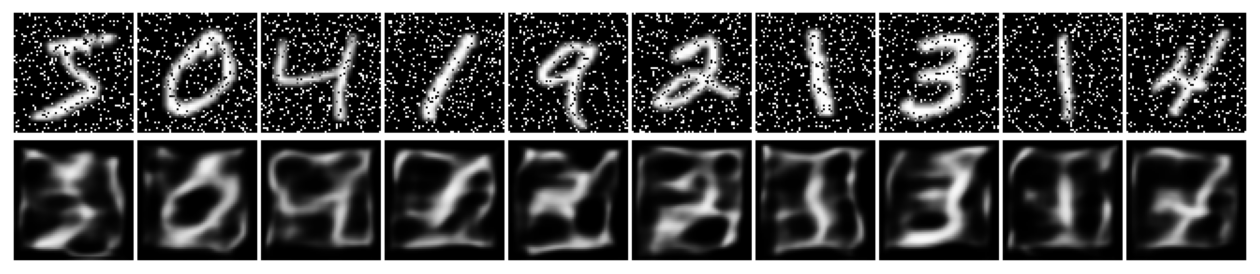

In [20]:
test_denoising(model)

------------------------------------------------------------


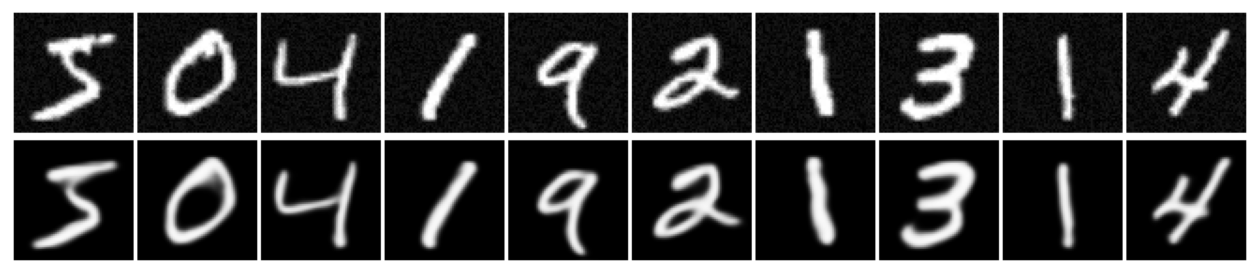

------------------------------------------------------------


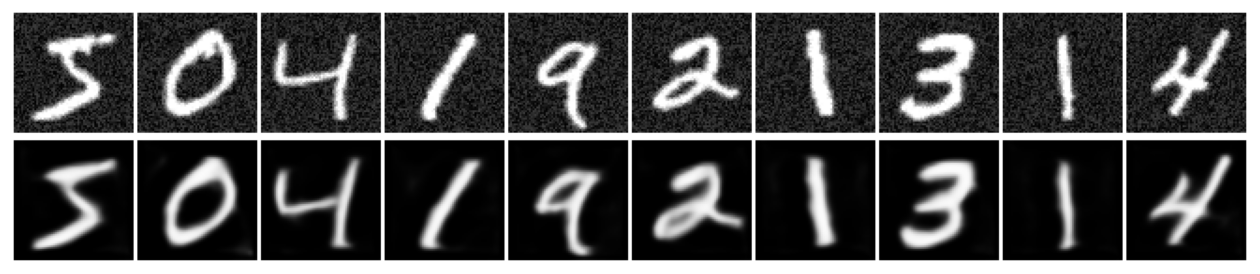

------------------------------------------------------------


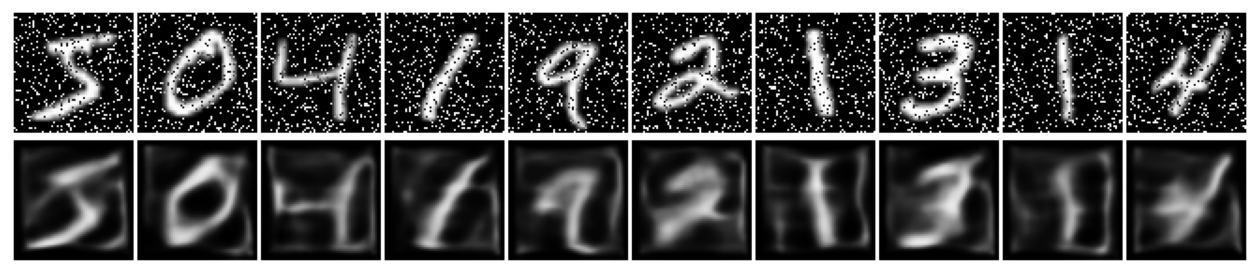

In [21]:
test_denoising(denoising_model)

### Теперь будем использовать метки классов

#### Возьмем 1000 объектов из тренировочной выборки, сделаем эмбеддинги, обучим на них модель классификации, посчитаем качество на валидационной

In [31]:
@torch.inference_mode()
def get_latent_labels(model, loader, count: int = None):
    model.eval()

    total = 0
    latent = []
    labels = []

    for x, y in loader:
        z = model.encode(x.to(device)).cpu()
        latent.append(z)
        labels.append(y)

        total += y.shape[0]
        if count is None or total>count:
            break
    latent = torch.cat(latent)[:count].numpy()
    labels = torch.cat(labels)[:count].numpy()
    return latent, labels

In [32]:
from sklearn.ensemble import RandomForestClassifier
X_train, y_train = get_latent_labels(denoising_model, train_loader, count = 1000)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [33]:
X_test, y_test = get_latent_labels(denoising_model, valid_loader)
predictions = clf.predict(X_test)
print(f'Accuracy is: {(predictions == y_test).mean()}')

Accuracy is: 0.953125
